In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


## Part 1 - Best-Seller Trends Across Categories

In [6]:
# Crosstab: proportion of best-sellers per category, sorted descending
df['isBestSeller'] = df['isBestSeller'].astype(bool)
ct = pd.crosstab(df['category'], df['isBestSeller'])
ct['pct_bestseller'] = ct[True] / ct.sum(axis=1) * 100
ct.sort_values('pct_bestseller', ascending=False).head(10)

isBestSeller,False,True,pct_bestseller
category,,,
Grocery,9008,556,5.813467
Smart Home Security & Lighting,98,6,5.769231
Health & Personal Care,9017,552,5.768628
Mobile Phone Accessories,248,11,4.247104
Power & Hand Tools,8353,306,3.533895
"Billiard, Snooker & Pool",241,8,3.212851
Pet Supplies,9152,285,3.020028
Home Brewing & Wine Making,239,7,2.845528
Wind Instruments,243,7,2.800000


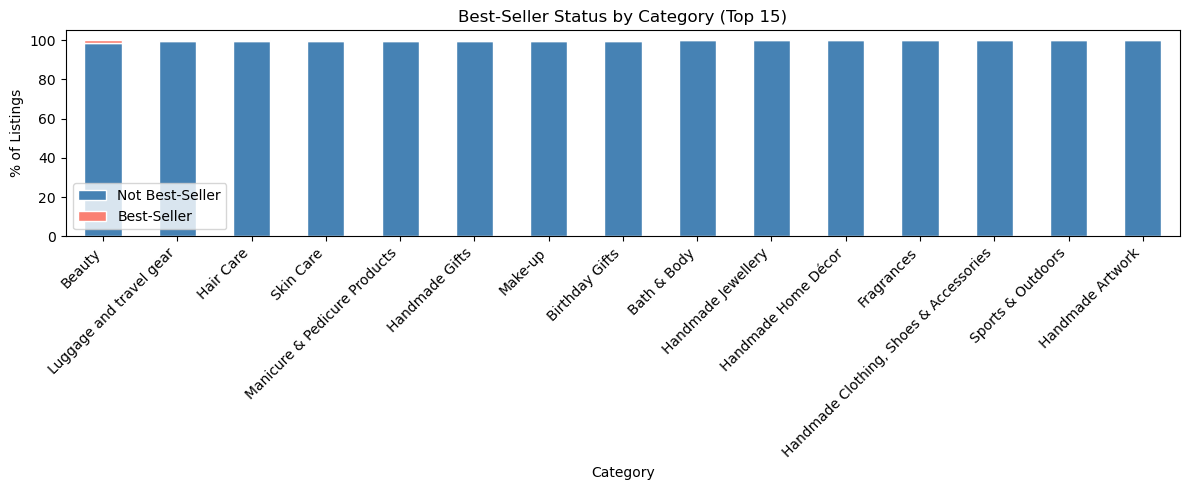

In [8]:
# Stacked bar chart - top 15 categories by listing count
top15_cats = df['category'].value_counts().head(15).index
ct_top15 = pd.crosstab(df[df['category'].isin(top15_cats)]['category'],
                        df[df['category'].isin(top15_cats)]['isBestSeller'],
                        normalize='index') * 100

ct_top15.sort_values(True, ascending=False).plot(
    kind='bar', stacked=True, figsize=(12, 5),
    color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Best-Seller Status by Category (Top 15)')
plt.xlabel('Category')
plt.ylabel('% of Listings')
plt.xticks(rotation=45, ha='right')
plt.legend(['Not Best-Seller', 'Best-Seller'])
plt.tight_layout()
plt.show()

## Part 2 - Prices and Ratings Across Categories

In [9]:
# Remove price outliers using IQR method
df['price'] = pd.to_numeric(df['price'], errors='coerce')
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 1.5 * IQR)].copy()
print(f'Rows before: {len(df):,}  After: {len(df_clean):,}  Removed: {len(df)-len(df_clean):,}')

Rows before: 2,443,651  After: 2,115,963  Removed: 327,688


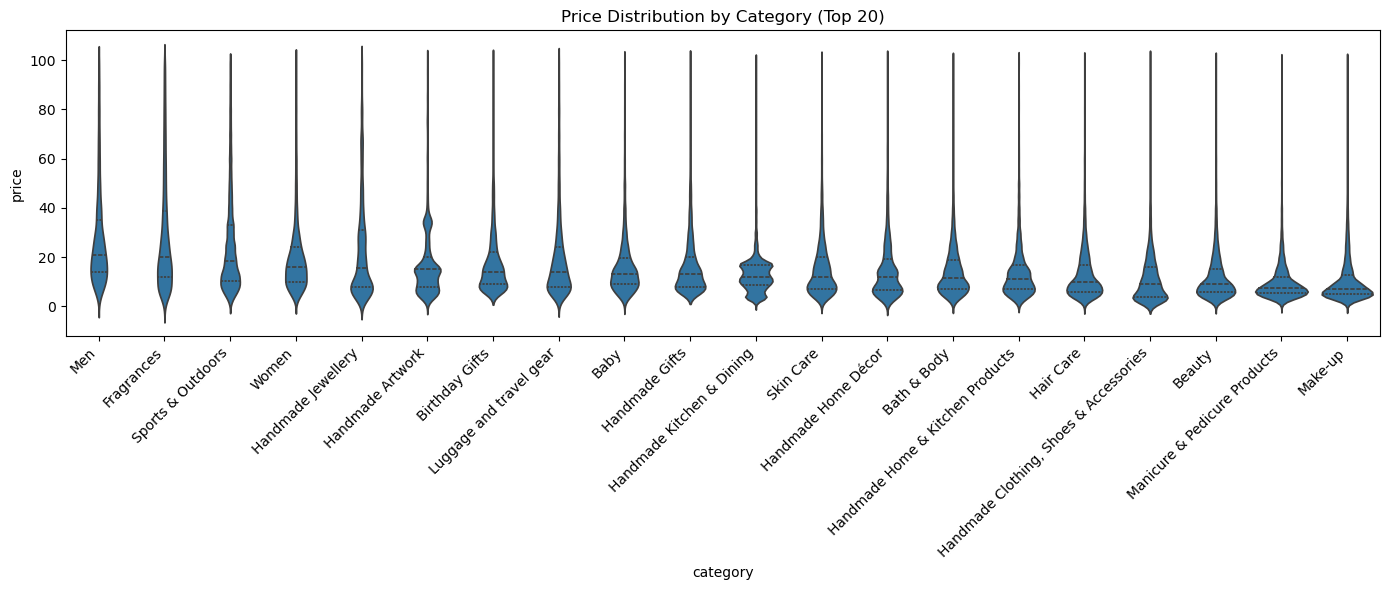

Highest median price (all categories):
category
Desktop PCs       74.00
Boxing Shoes      69.79
Tablets           69.00
Graphics Cards    68.54
Motherboards      67.92
Name: price, dtype: float64


In [10]:
# Violin plot - price across top 20 categories
top20_cats = df_clean['category'].value_counts().head(20).index
df_top20 = df_clean[df_clean['category'].isin(top20_cats)]

plt.figure(figsize=(14, 6))
order = df_top20.groupby('category')['price'].median().sort_values(ascending=False).index
sns.violinplot(data=df_top20, x='category', y='price', order=order, inner='quartile')
plt.title('Price Distribution by Category (Top 20)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highest median price across ALL categories
print('Highest median price (all categories):')
print(df_clean.groupby('category')['price'].median().sort_values(ascending=False).head(5))

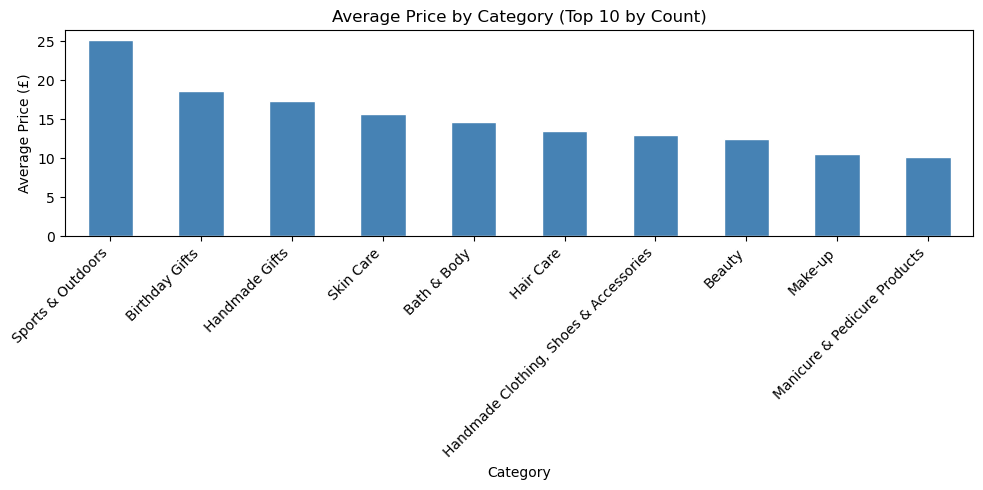

Highest average price (all categories):
category
Motherboards      68.772432
Boxing Shoes      67.417803
Desktop PCs       66.915562
Tablets           66.552971
Graphics Cards    65.103509
Name: price, dtype: float64


In [11]:
# Bar chart - average price, top 10 categories by count
top10_cats = df_clean['category'].value_counts().head(10).index
avg_price = df_clean[df_clean['category'].isin(top10_cats)].groupby('category')['price'].mean().sort_values(ascending=False)

avg_price.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.title('Average Price by Category (Top 10 by Count)')
plt.xlabel('Category')
plt.ylabel('Average Price (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highest average price across ALL categories
print('Highest average price (all categories):')
print(df_clean.groupby('category')['price'].mean().sort_values(ascending=False).head(5))

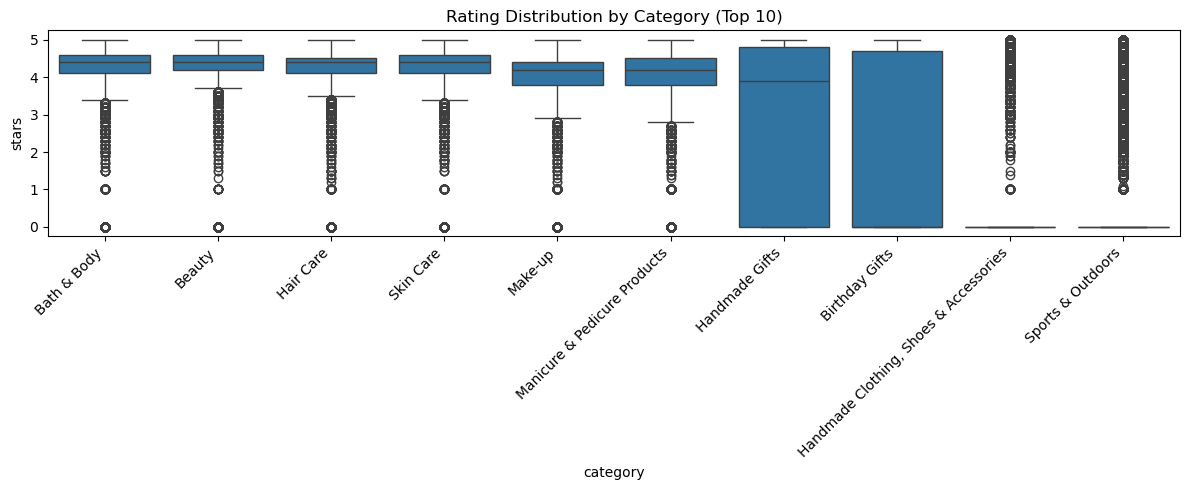

Highest median rating (all categories):
category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Name: stars, dtype: float64


In [ ]:
df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
df_top10 = df_clean[df_clean['category'].isin(top10_cats)]

plt.figure(figsize=(12, 5))
order = df_top10.groupby('category')['stars'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top10, x='category', y='stars', order=order)
plt.title('Rating Distribution by Category (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highest median rating across ALL categories
print('Highest median rating (all categories):')
print(df_clean.groupby('category')['stars'].median().sort_values(ascending=False).head(5))

## Part 3 - Price vs Rating

In [13]:
# Correlation coefficient
corr = df_clean[['price', 'stars']].dropna().corr()
print(corr)

          price     stars
price  1.000000 -0.077673
stars -0.077673  1.000000


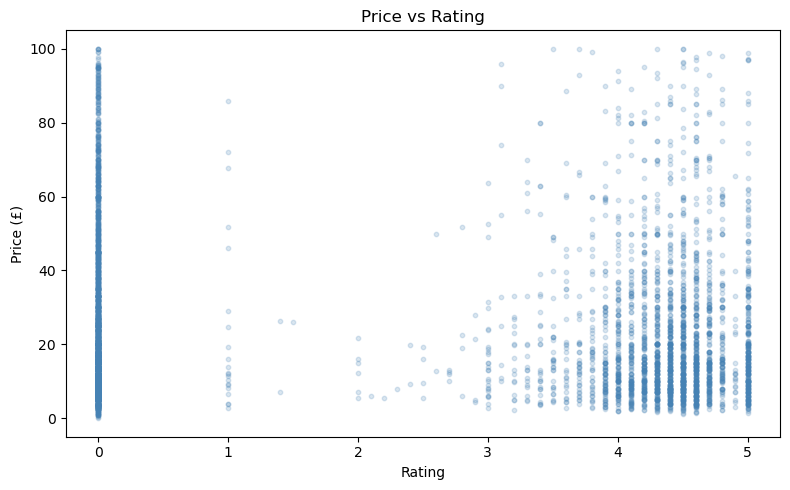

In [14]:
# Scatter plot - price vs rating
sample = df_clean[['price', 'stars']].dropna().sample(min(5000, len(df_clean)), random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample['stars'], sample['price'], alpha=0.2, s=10, color='steelblue')
plt.title('Price vs Rating')
plt.xlabel('Rating')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()

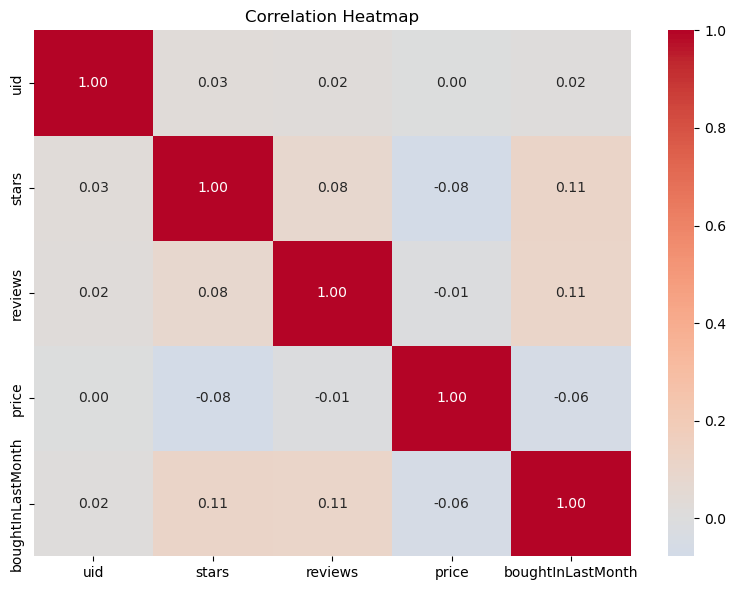

In [15]:
# Correlation heatmap - all numerical columns
num_cols = df_clean.select_dtypes(include='number').drop(columns=['isBestSeller'], errors='ignore')
plt.figure(figsize=(8, 6))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

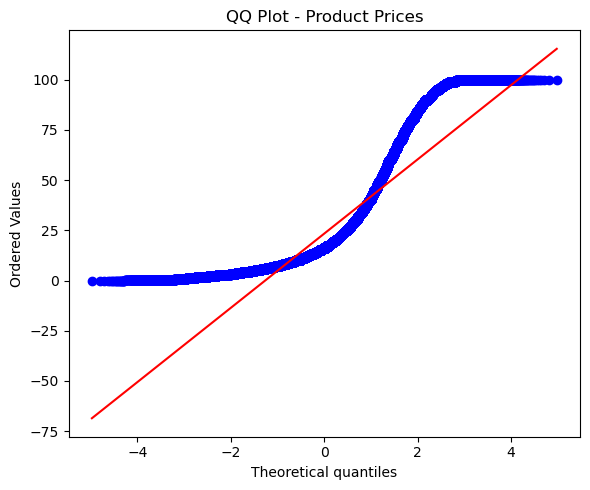

In [16]:
# QQ plot - do prices follow a normal distribution?
plt.figure(figsize=(6, 5))
stats.probplot(df_clean['price'].dropna(), dist='norm', plot=plt)
plt.title('QQ Plot - Product Prices')
plt.tight_layout()
plt.show()

In [17]:
# Correlation with outliers
print('Correlation (with outliers):')
print(df[['price', 'stars']].dropna().corr())

Correlation (with outliers):
          price     stars
price  1.000000 -0.124907
stars -0.124907  1.000000


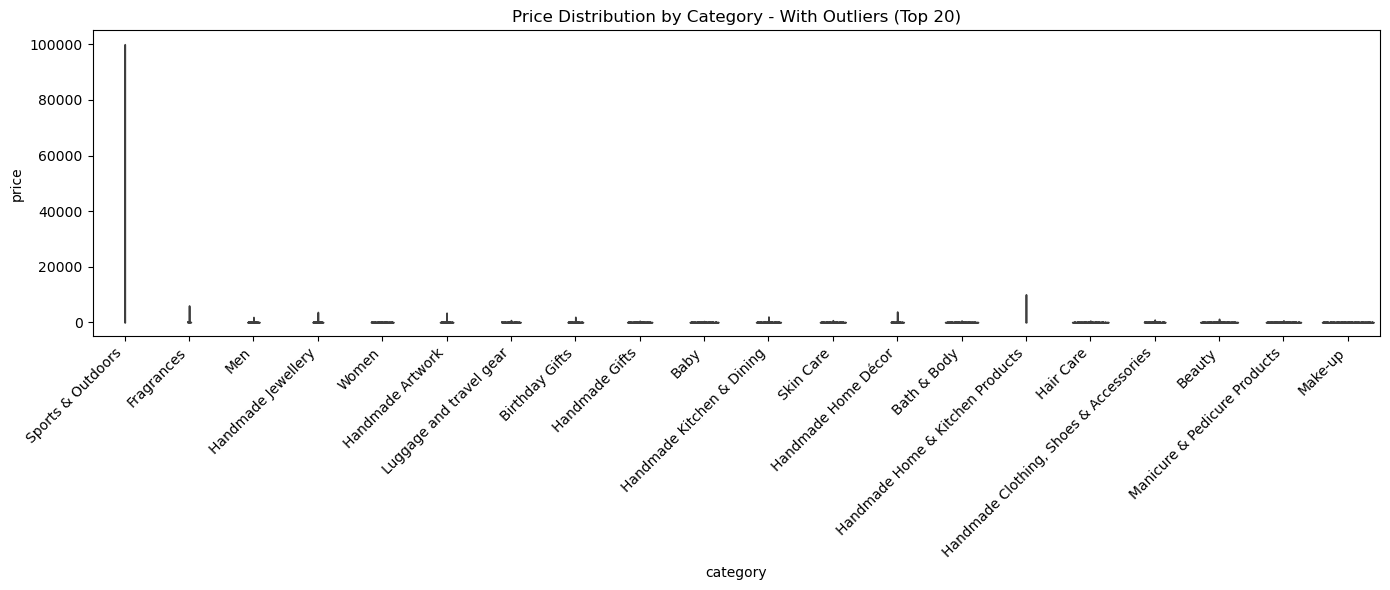

In [18]:
# Violin plot with outliers - top 20
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
top20_raw = df['category'].value_counts().head(20).index
df_top20_raw = df[df['category'].isin(top20_raw)]

plt.figure(figsize=(14, 6))
order_raw = df_top20_raw.groupby('category')['price'].median().sort_values(ascending=False).index
sns.violinplot(data=df_top20_raw, x='category', y='price', order=order_raw, inner='quartile')
plt.title('Price Distribution by Category - With Outliers (Top 20)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

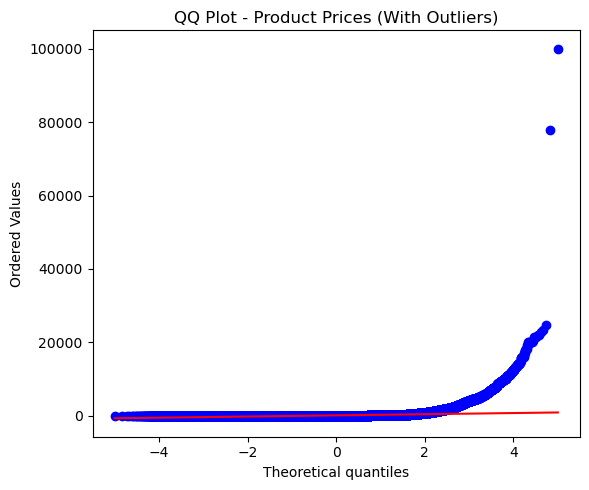

In [19]:
# QQ plot with outliers
plt.figure(figsize=(6, 5))
stats.probplot(df['price'].dropna(), dist='norm', plot=plt)
plt.title('QQ Plot - Product Prices (With Outliers)')
plt.tight_layout()
plt.show()